# Week 3: BSM Simple Chooser Option Validation

## Objective

This notebook validates the Black-Scholes-Merton simple chooser option model.

A simple chooser option allows the holder to choose at time $T_1$ whether
the contract becomes a European call or put. Both choices share the same
strike $K$ and final maturity $T_2$.

This notebook includes:

1. Paper baseline pricing case;
2. Data-driven JPM pricing case;
3. Formula validation checks;
4. Volatility sensitivity analysis.


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "config").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

from src.bsm_chooser import simple_chooser_price

CONFIG_PATH = PROJECT_ROOT / "config" / "chooser_bsm_config.json"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "week_3"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with CONFIG_PATH.open("r", encoding="utf-8") as file:
    config = json.load(file)

print("Project root:", PROJECT_ROOT)
print("Configuration loaded successfully.")


Project root: D:\Users\Lenovo\Desktop\chooser-option-pricing
Configuration loaded successfully.


## 1. Pricing function

For the zero-dividend simple chooser used in Week 3:

$$
V_{chooser} = C(S, K, T_2) +
P(S, K e^{-r(T_2-T_1)}, T_1)
$$

where:

- $S$: spot price;
- $K$: strike price;
- $T_1$: choice date;
- $T_2$: final maturity;
- $r$: risk-free rate;
- $\sigma$: annualized volatility.


In [2]:
def price_case(case_name: str) -> dict:
    parameters = config[case_name]

    result = simple_chooser_price(
        spot_price=parameters["spot_price"],
        strike=parameters["strike"],
        choice_time_years=parameters["choice_time_years"],
        maturity_years=parameters["maturity_years"],
        risk_free_rate=parameters["risk_free_rate"],
        volatility=parameters["volatility"],
        dividend_yield=parameters["dividend_yield"],
    )

    return {
        "case": case_name,
        "spot_price": parameters["spot_price"],
        "strike": parameters["strike"],
        "choice_time_years": parameters["choice_time_years"],
        "maturity_years": parameters["maturity_years"],
        "risk_free_rate": parameters["risk_free_rate"],
        "volatility": parameters["volatility"],
        **result,
    }


paper_result = price_case("paper_baseline")
jpm_result = price_case("data_driven_case")

results = pd.DataFrame([paper_result, jpm_result])
results.round(4)


,case,spot_price,strike,choice_time_years,maturity_years,risk_free_rate,volatility,call_component,adjusted_put_strike,choice_put_component,chooser_price
0,paper_baseline,150.00,150.0,0.5,1.0,0.0500,0.3000,21.3469,146.2965,9.0442,30.3910
1,data_driven_case,239.71,150.0,0.5,1.0,0.0458,0.3076,97.5277,146.6040,0.1207,97.6485


## 2. Initial validation

The paper baseline is expected to produce a simple chooser price close to
`30.3910`. The chooser price should not be lower than its call component.


In [3]:
assert abs(paper_result["chooser_price"] - 30.3910) < 1e-4
assert paper_result["chooser_price"] >= paper_result["call_component"]

print("Paper baseline validation passed.")
print(f"Paper baseline chooser price: {paper_result['chooser_price']:.4f}")
print(f"JPM data-driven chooser price: {jpm_result['chooser_price']:.4f}")


Paper baseline validation passed.
Paper baseline chooser price: 30.3910
JPM data-driven chooser price: 97.6485


## 3. Volatility sensitivity analysis

BSM assumes volatility is constant. This chart changes the annualized
volatility while keeping all other paper baseline parameters fixed.

The purpose is to show why volatility estimation is important for the
later machine-learning stage of this project.


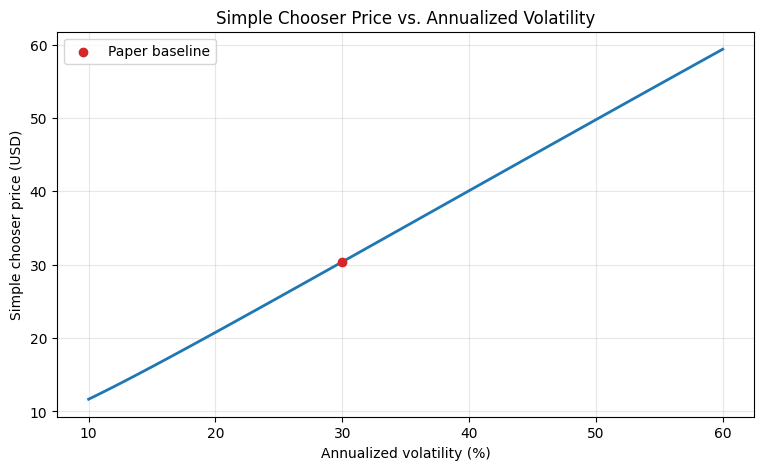

Figure saved to: D:\Users\Lenovo\Desktop\chooser-option-pricing\outputs\week_3\chooser_price_vs_volatility.png


In [4]:
baseline = config["paper_baseline"].copy()
volatility_values = np.linspace(0.10, 0.60, 51)

chooser_prices = []
for volatility in volatility_values:
    result = simple_chooser_price(
        spot_price=baseline["spot_price"],
        strike=baseline["strike"],
        choice_time_years=baseline["choice_time_years"],
        maturity_years=baseline["maturity_years"],
        risk_free_rate=baseline["risk_free_rate"],
        volatility=float(volatility),
        dividend_yield=baseline["dividend_yield"],
    )
    chooser_prices.append(result["chooser_price"])

plt.figure(figsize=(9, 5))
plt.plot(volatility_values * 100, chooser_prices, color="#1f77b4", linewidth=2)
plt.scatter(
    baseline["volatility"] * 100,
    paper_result["chooser_price"],
    color="#d62728",
    zorder=3,
    label="Paper baseline",
)
plt.title("Simple Chooser Price vs. Annualized Volatility")
plt.xlabel("Annualized volatility (%)")
plt.ylabel("Simple chooser price (USD)")
plt.grid(alpha=0.3)
plt.legend()

figure_path = OUTPUT_DIR / "chooser_price_vs_volatility.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to:", figure_path)


## 4. Initial conclusion

1. The BSM simple chooser model runs successfully for both the paper baseline
   and the JPM data-driven case.
2. The baseline validation result is `30.3910`.
3. The chooser price rises as volatility increases, because the right to defer
   the call-or-put decision becomes more valuable.
4. This confirms the main BSM limitation to be addressed later: volatility is
   treated as constant, while real market volatility changes over time.
